# This notebook is used to prototype filters for extending the framework to multiple partitions

In [1]:
import filters
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import helpers

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [10, 5]
EPSILON = 1e-5

## Original filters used for multistep framework

In [2]:
ells = [3, 10, 35, 70]
deltas = [2, 2, 2, 2]
sigma2s = [1, 1, 1, 1, 1]
names = ["<3", "3-10", "10-35", "35-70", ">70"]
colours = ["teal", "crimson", "forestgreen", "violet", "blue"]
plot_mask = [True, True, True, True, True]

### Compute and plot transfer functions

/home/sunwang/radio-imaging/notebooks_and_pyscripts/filters.py:215: RuntimeWarning: divide by zero encountered in log10
  curr_vals = 20 * np.log10(np.abs(filter_vals[i]))


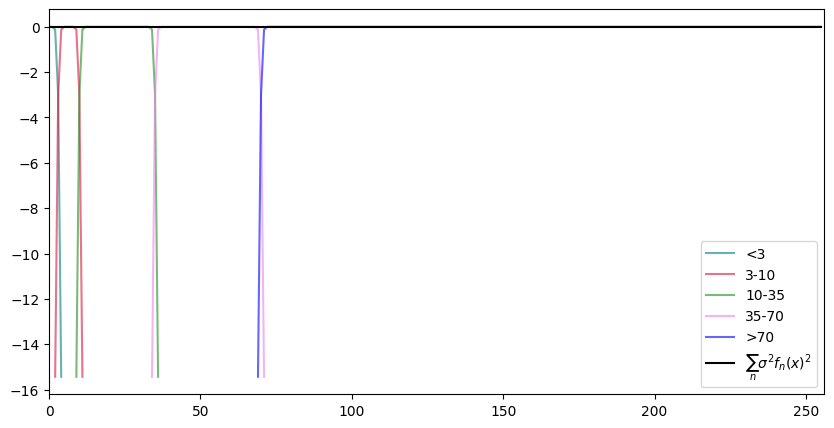

/home/sunwang/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


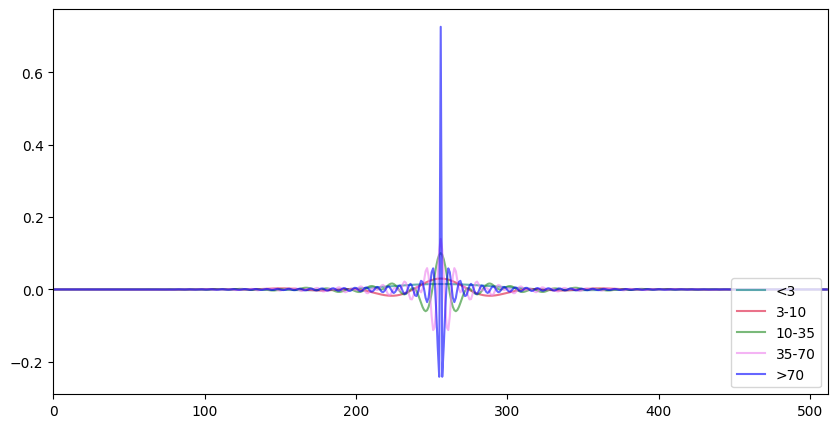

In [3]:
filter_vals, xvals, filter_sum = filters.create_filters_mstep(256, deltas, ells, sigma2s)
filter_sum = np.array(filter_sum)
filter_vals_nparr = [np.array(filt) for filt in filter_vals]

filters.plot_filters(names, filter_vals_nparr, filter_sum, colours, plot_mask, dbscale=True)

filters_spatial = filters.compute_spatial_filters(filter_vals_nparr)
filters.plot_filters(names, filters_spatial, None, colours, plot_mask, spatial=True)

mstep_spatial = filters_spatial
mstep_freq = filter_vals_nparr

### and in 2d

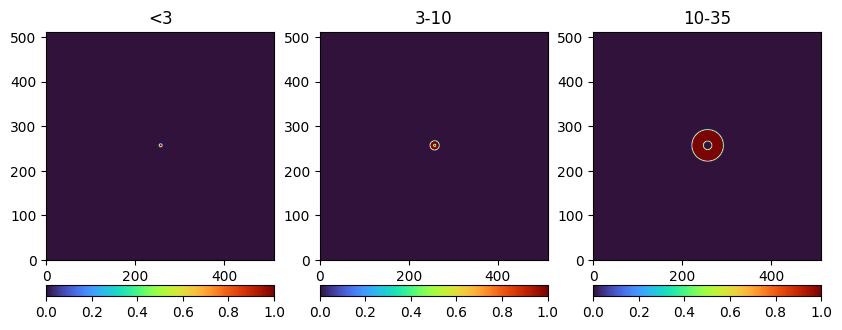

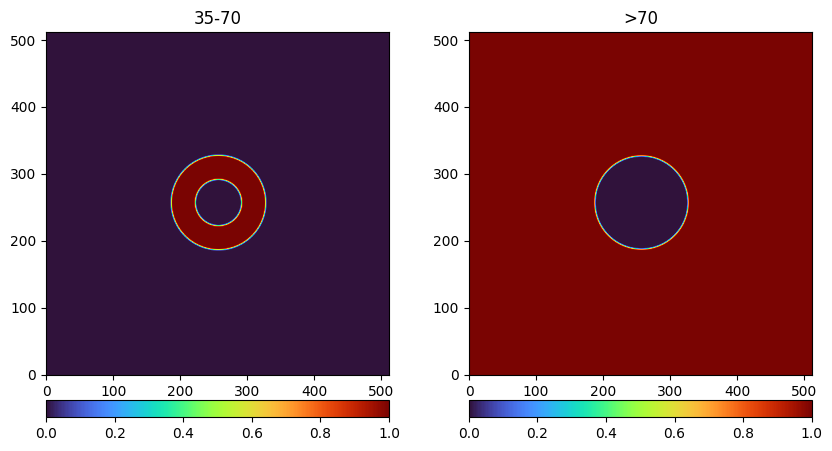

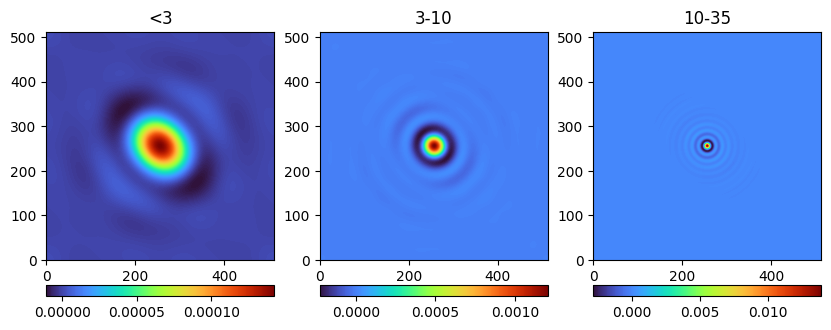

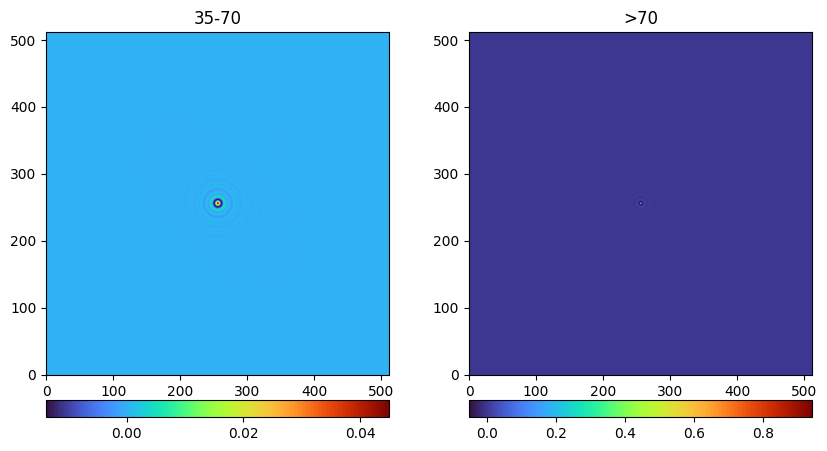

In [4]:
filts2d_mstep = [filters.freq1d_to_radial2d(filtfreq1d, 512) for filtfreq1d in filter_vals_nparr]

helpers.plotNImages([np.abs(filts2d_mstep[0][0]), np.abs(filts2d_mstep[1][0]), np.abs(filts2d_mstep[2][0])], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([np.abs(filts2d_mstep[3][0]), np.abs(filts2d_mstep[4][0])], ["35-70", ">70"], cmap=cmap)

helpers.plotNImages([filts2d_mstep[0][1], filts2d_mstep[1][1], filts2d_mstep[2][1]], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([filts2d_mstep[3][1], filts2d_mstep[4][1]], ["35-70", ">70"], cmap=cmap)

## Windowed Sinc

At a cursory glance, this filter, with the kaiser window, seems to behave very similarly to what is used in the multi-step method, given a somewhat large window and $\beta$.

### Lowpass prototype visualization

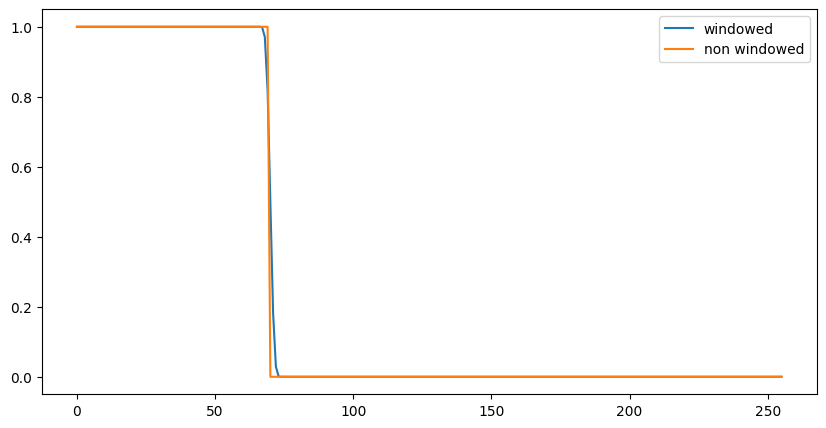

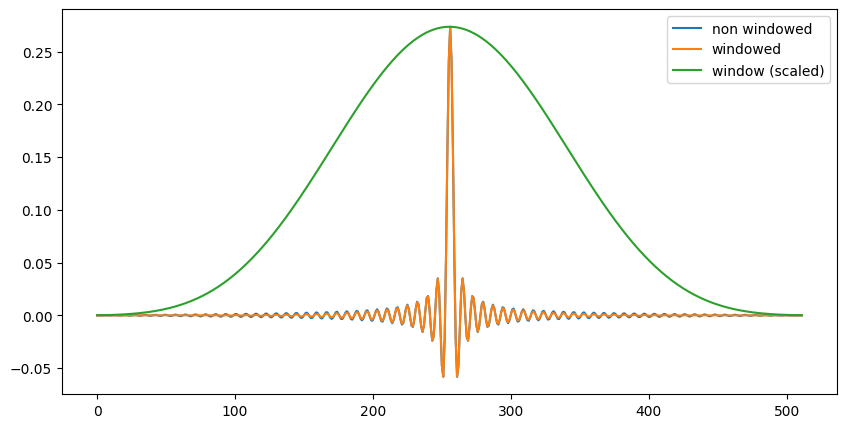

In [5]:
tf_nw, spatial_nw, tf_w, spatial_w, window = filters.windowed_sinc_lp(70, 512, 512, "kaiser", kaiser_beta=10)
plt.plot(tf_w.real, label="windowed")
plt.plot(tf_nw.real, label="non windowed")
plt.legend(loc="upper right")
plt.show()
plt.plot(spatial_nw, label="non windowed")
plt.plot(spatial_w, label="windowed")
window = window * np.max(spatial_nw)
plt.plot(window, label="window (scaled)")
plt.legend(loc="upper right")
plt.show()

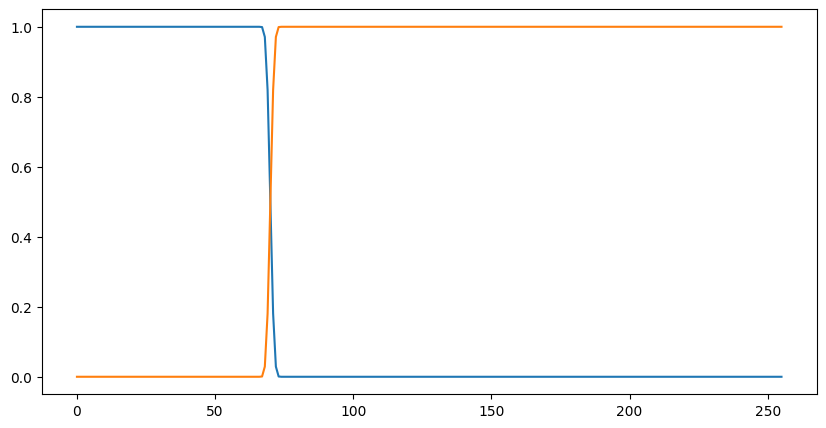

In [6]:
shifted = filters.lp_to_hp(spatial_w)
plt.plot(tf_w.real)
plt.plot(shifted[0].real)
plt.show()

### Filter bank visualization

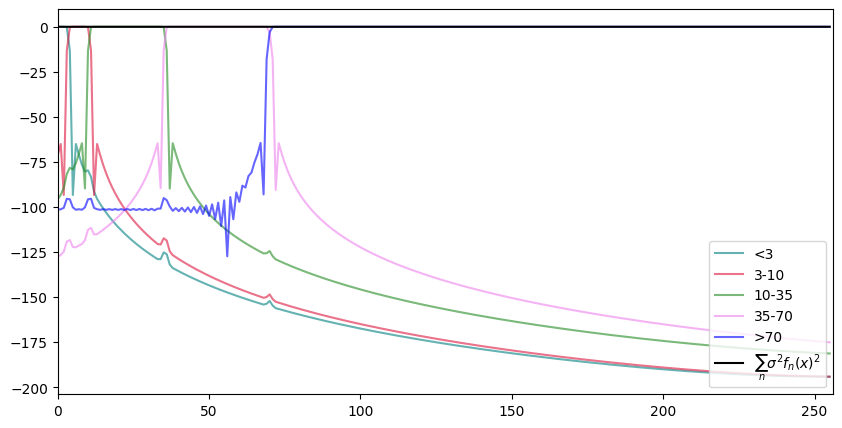

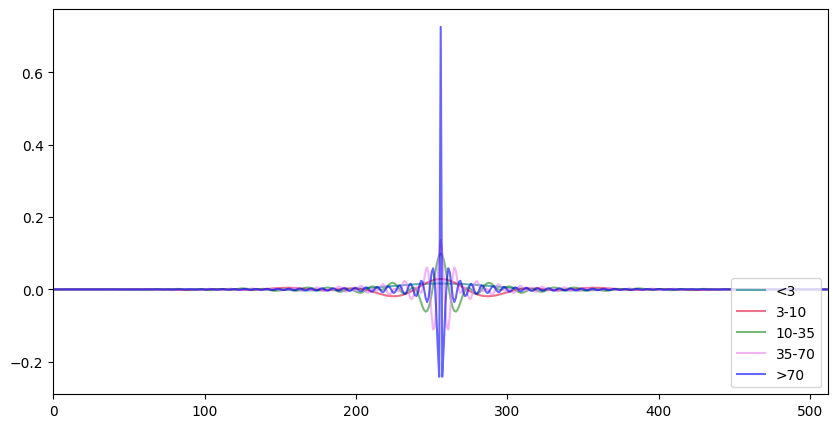

In [7]:
sigma2s = [1, 1, 1, 1, 1]
names = ["<3", "3-10", "10-35", "35-70", ">70"]
colours = ["teal", "crimson", "forestgreen", "violet", "blue"]
plot_mask = [True, True, True, True, True]

windowed_sinc_filters = []

_, _, _, spatial_w, _ = filters.windowed_sinc_lp(3, 512, 512, "kaiser", kaiser_beta=5)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, 0)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((10 - 3)//2, 512, 512, "kaiser", kaiser_beta=5)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (10 + 3)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((35-10)//2, 512, 512, "kaiser", kaiser_beta=5)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (35 + 10)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((70-35)//2, 512, 512, "kaiser", kaiser_beta=5)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (70 + 35)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp(70, 512, 512, "kaiser", kaiser_beta=5)
windowed_sinc_filters.append(filters.lp_to_hp(spatial_w)[0])

normalized_filters, filter_sum = filters.normalize_filters(windowed_sinc_filters, sigma2s)

filters.plot_filters(names, normalized_filters, filter_sum, colours, plot_mask, dbscale=True)

filters_spatial = filters.compute_spatial_filters(normalized_filters)
filters.plot_filters(names, filters_spatial, None, colours, plot_mask, spatial=True)

wsinc_freq = normalized_filters
wsinc_spatial = filters_spatial

### In 2D

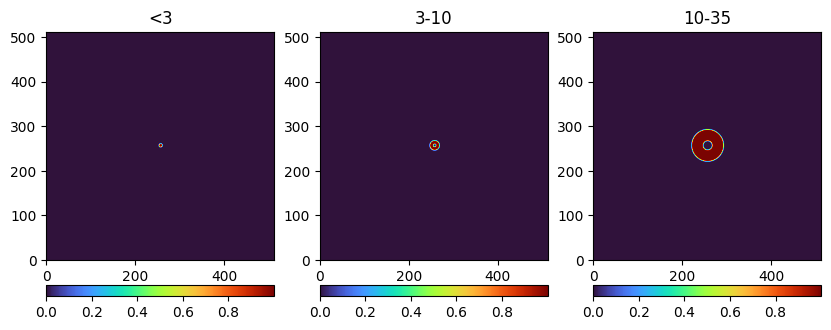

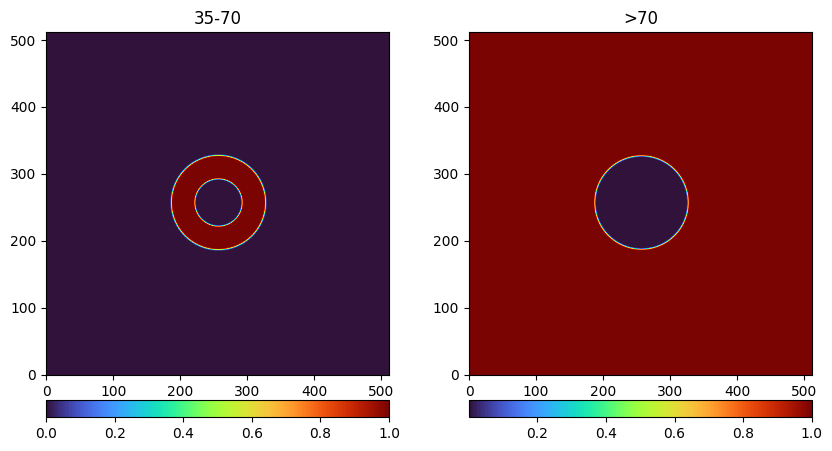

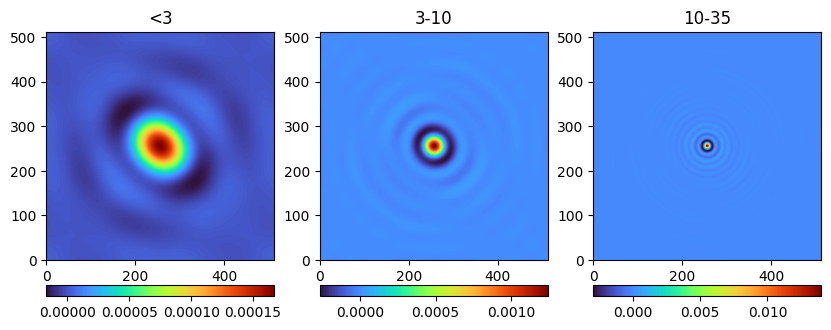

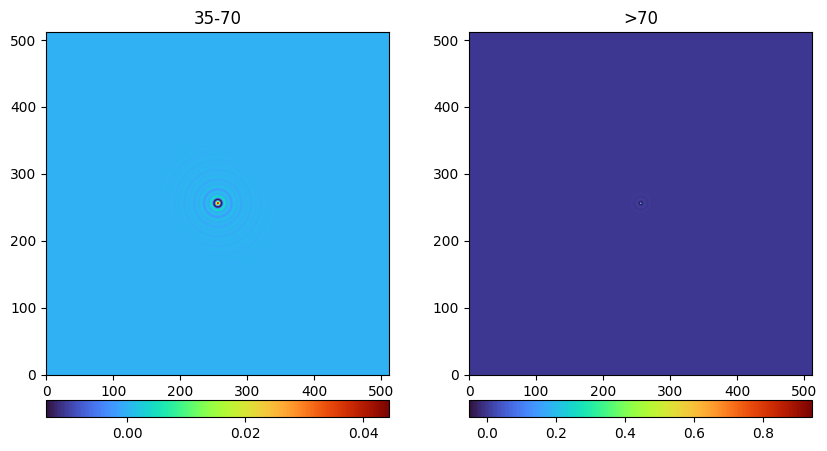

In [8]:
filts2d_wsinc = [filters.freq1d_to_radial2d(filtfreq1d, 512) for filtfreq1d in normalized_filters]

helpers.plotNImages([np.abs(filts2d_wsinc[0][0]), np.abs(filts2d_wsinc[1][0]), np.abs(filts2d_wsinc[2][0])], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([np.abs(filts2d_wsinc[3][0]), np.abs(filts2d_wsinc[4][0])], ["35-70", ">70"], cmap=cmap)

helpers.plotNImages([filts2d_wsinc[0][1], filts2d_wsinc[1][1], filts2d_wsinc[2][1]], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([filts2d_wsinc[3][1], filts2d_wsinc[4][1]], ["35-70", ">70"], cmap=cmap)

## Parks McClellan

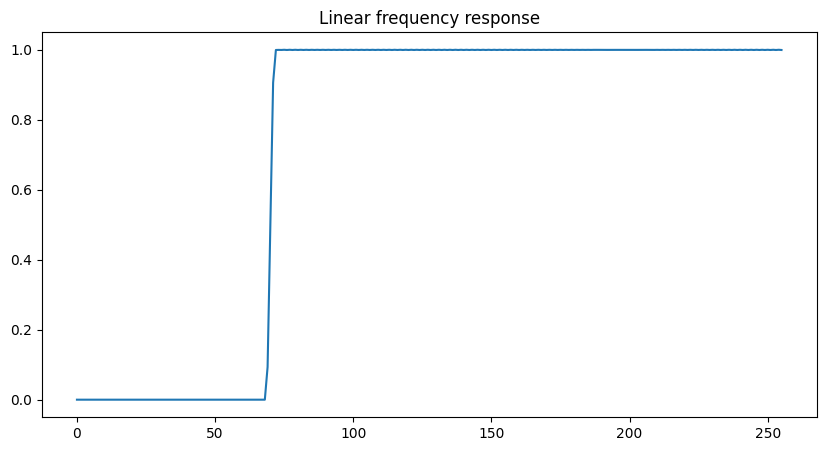

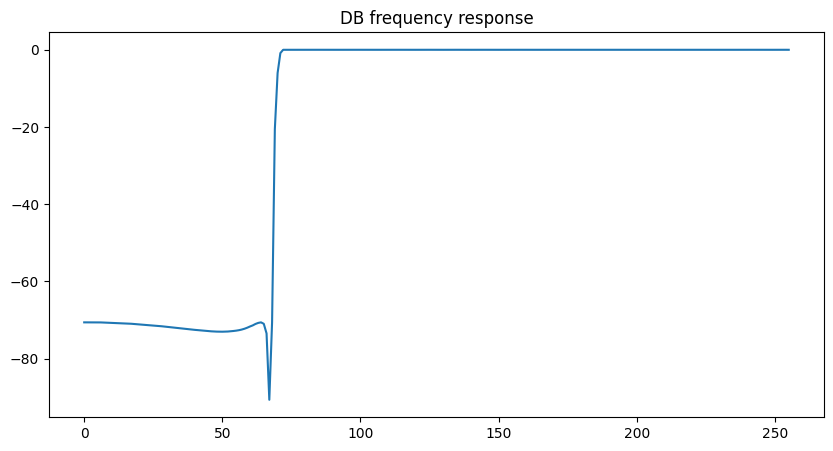

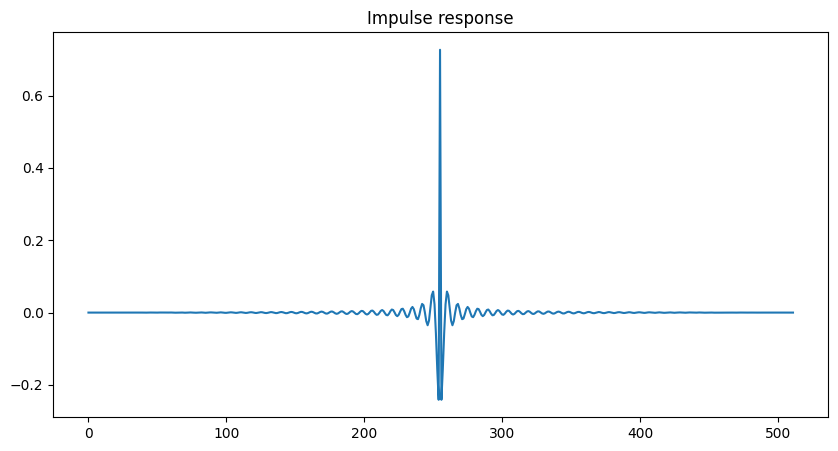

In [9]:
passband = [70, 256]
freq, spatial = filters.parks_mcclellan_lp(passband, 2, 512, 1)
plt.plot(np.abs(freq))
plt.title("Linear frequency response")
plt.show()
plt.plot(20*np.log10(np.abs(freq)))
plt.title("DB frequency response")
plt.show()
plt.plot(spatial.real)
plt.title("Impulse response")
plt.show()

### Filter bank visualization

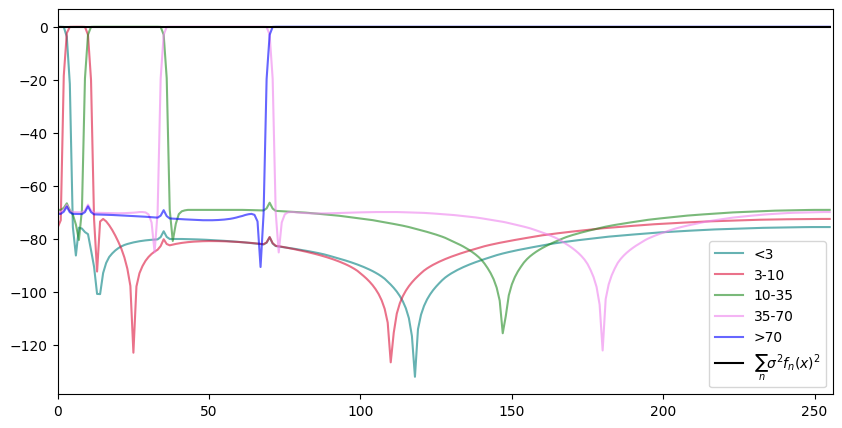

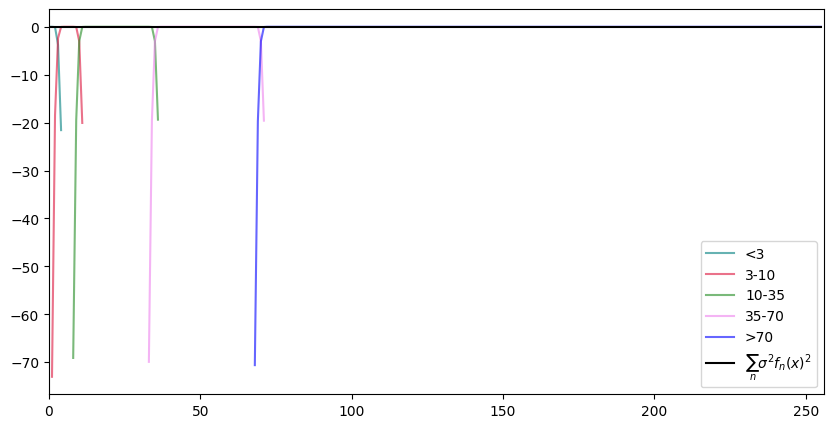

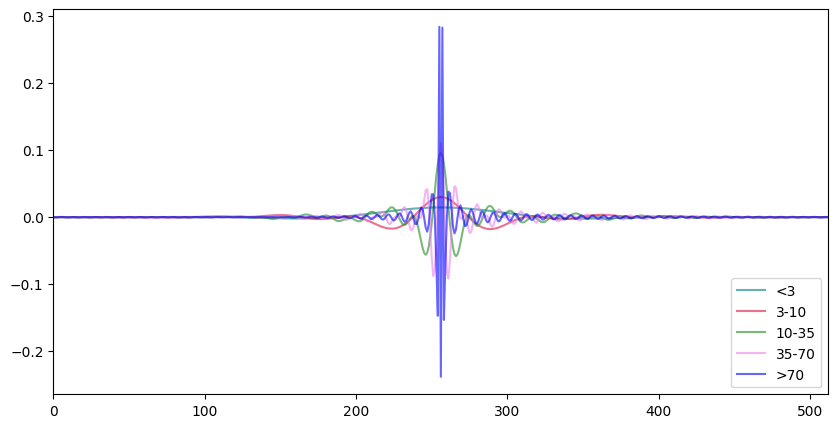

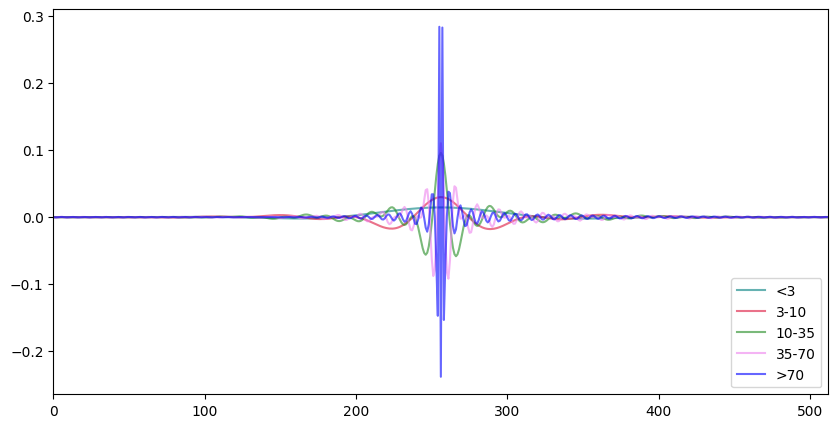

In [10]:
sigma2s = [1, 1, 1, 1, 1]
ells = [3, 10, 35, 70]
passbands = [[0, ells[0]]]
hw = 2
colours = ["teal", "crimson", "forestgreen", "violet", "blue"]
plot_mask = [True, True, True, True, True]

for i, ell in enumerate(ells):
    if i == len(ells) - 1:
        passbands.append([ell, 256])
    else:
        passbands.append([ell, ells[i+1]])
        
cutoffs = filters.compute_cutoffs(ells, hw, 256)
        
filts = [filters.parks_mcclellan_lp(passbands[i], 2, 512, sigma2s[i]) for i in range(len(passbands))]

freq_filts, spatial_filts = list(zip(*filts))

normalized_filters, filter_sum = filters.normalize_filters(freq_filts, sigma2s)
normalized_filters_cut, filter_sum_cut = filters.normalize_filters(freq_filts, sigma2s, cutoffs)

filters_spatial_orig = filters.compute_spatial_filters(normalized_filters)
filters_spatial_cut = filters.compute_spatial_filters(normalized_filters_cut)

filters.plot_filters(names, normalized_filters, filter_sum, colours, plot_mask, dbscale=True)
filters.plot_filters(names, normalized_filters_cut, filter_sum_cut, colours, plot_mask, dbscale=True)

filters.plot_filters(names, filters_spatial_orig, filter_sum, colours, plot_mask, spatial=True)
filters.plot_filters(names, filters_spatial_cut, filter_sum, colours, plot_mask, spatial=True)

pm_freq = normalized_filters
pmcut_freq = normalized_filters_cut
pm_spatial = filters_spatial_orig
pmcut_spatial = filters_spatial_cut

### Filter bank in 2D achieved using linear interpolation

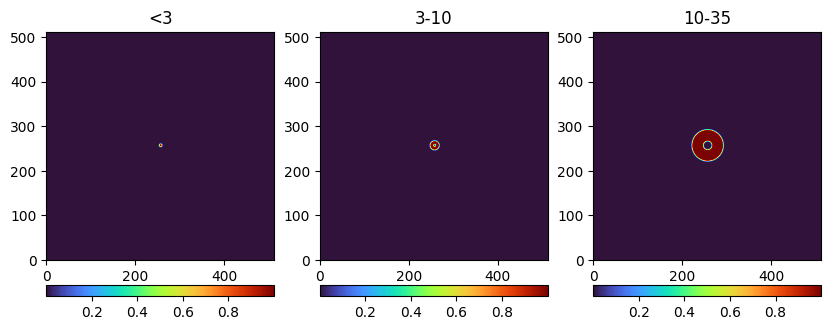

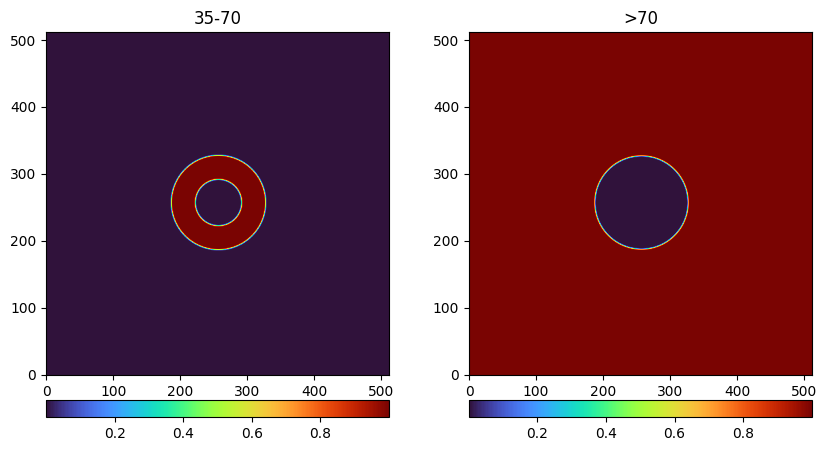

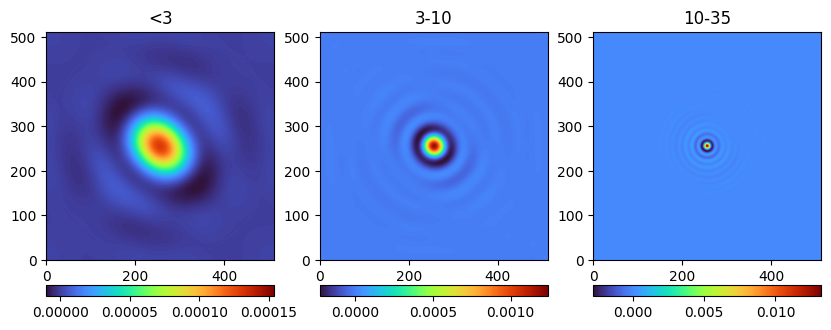

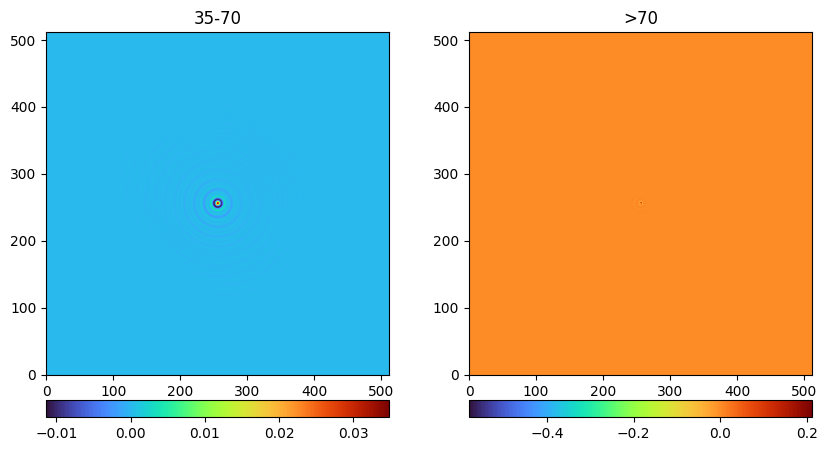

In [11]:
filts2d_pm = [filters.freq1d_to_radial2d(filtfreq1d, 512) for filtfreq1d in normalized_filters]

helpers.plotNImages([np.abs(filts2d_pm[0][0]), np.abs(filts2d_pm[1][0]), np.abs(filts2d_pm[2][0])], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([np.abs(filts2d_pm[3][0]), np.abs(filts2d_pm[4][0])], ["35-70", ">70"], cmap=cmap)

helpers.plotNImages([filts2d_pm[0][1], filts2d_pm[1][1], filts2d_pm[2][1]], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([filts2d_pm[3][1], filts2d_pm[4][1]], ["35-70", ">70"], cmap=cmap)

### And for filters that have tails cut off

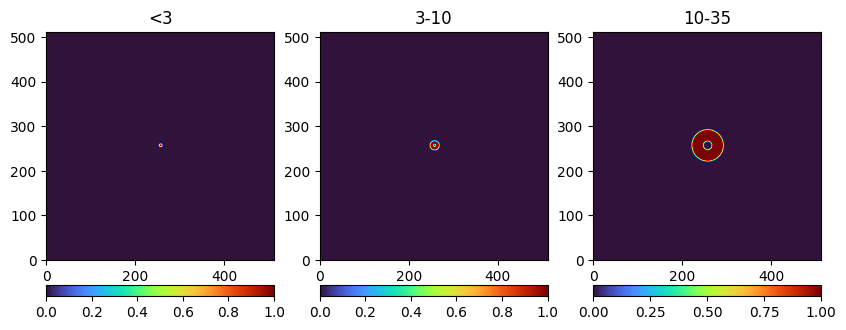

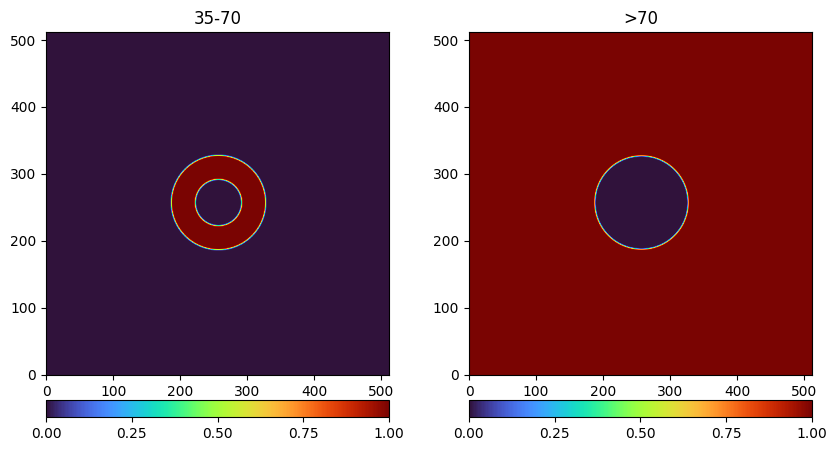

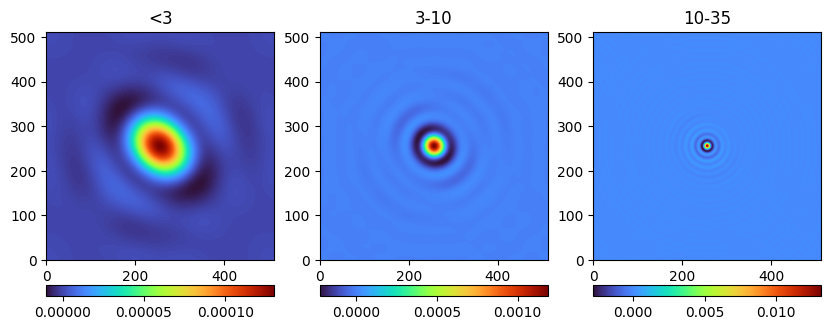

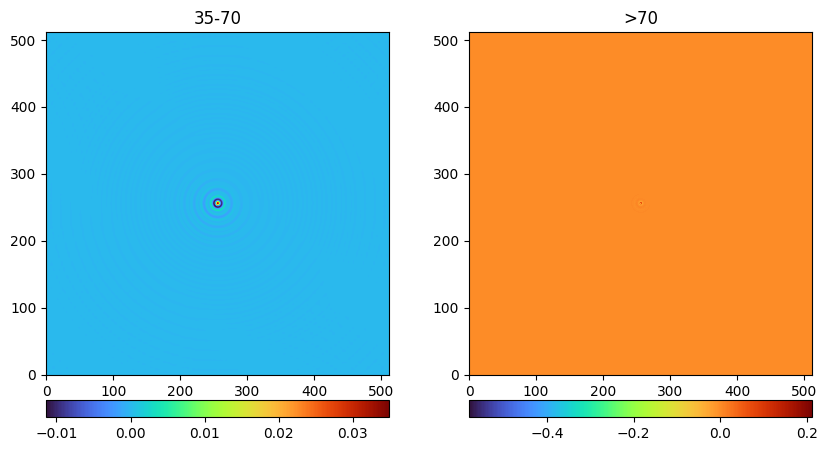

In [12]:
filts2d_pmcut = [filters.freq1d_to_radial2d(filtfreq1d, 512) for filtfreq1d in normalized_filters_cut]

helpers.plotNImages([np.abs(filts2d_pmcut[0][0]), np.abs(filts2d_pmcut[1][0]), np.abs(filts2d_pmcut[2][0])], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([np.abs(filts2d_pmcut[3][0]), np.abs(filts2d_pmcut[4][0])], ["35-70", ">70"], cmap=cmap)

helpers.plotNImages([filts2d_pmcut[0][1], filts2d_pmcut[1][1], filts2d_pmcut[2][1]], ["<3", "3-10", "10-35"], cmap=cmap)
helpers.plotNImages([filts2d_pmcut[3][1], filts2d_pmcut[4][1]], ["35-70", ">70"], cmap=cmap)

## Filters compared

In [13]:
band_idx = 3

labels = ["mstep", "wsinc kaiser 5-512", "pmac", "pmac cut"]
cols = ["red", "green", "blue", "black"]
mask = [True, True, True, True]

freq = [mstep_freq[band_idx], wsinc_freq[band_idx], pm_freq[band_idx], pmcut_freq[band_idx]]
spatial = [mstep_spatial[band_idx], wsinc_spatial[band_idx], pm_spatial[band_idx], pmcut_spatial[band_idx]]
filts2d = [filts2d_mstep[band_idx], filts2d_wsinc[band_idx], filts2d_pm[band_idx], filts2d_pmcut[band_idx]]

#### Frequency and spatial comparisons

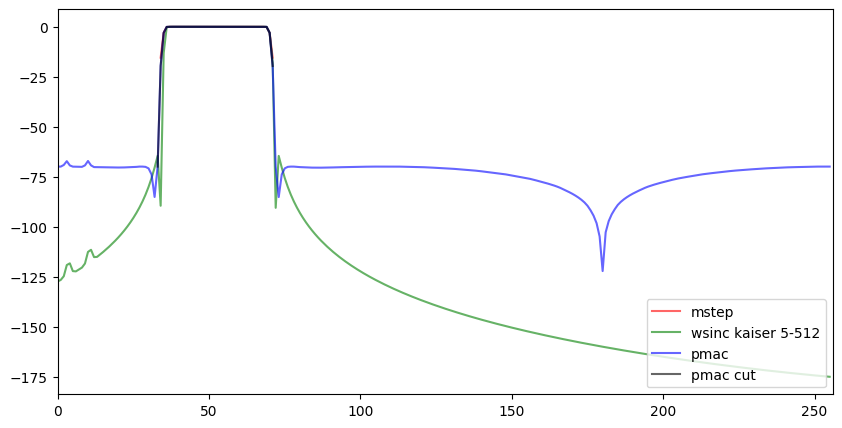

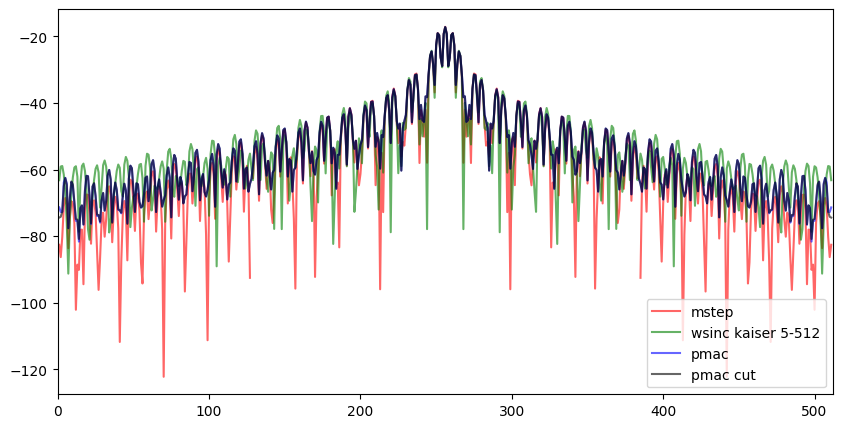

In [14]:
filters.plot_filters(labels, freq, None, cols, mask, dbscale=True)
filters.plot_filters(labels, spatial, None, cols, mask, spatial=True, dbscale=True)

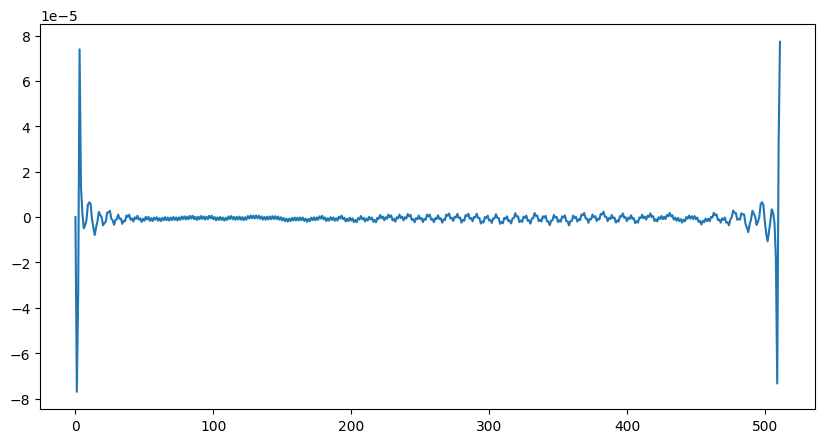

In [15]:
plt.plot(spatial[2] - spatial[3])
plt.show()

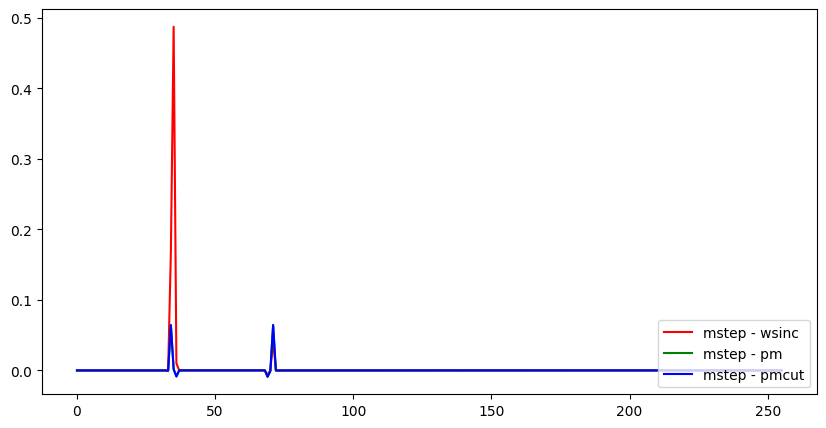

In [16]:
plt.plot(np.abs(freq[0])-np.abs(freq[1]), label="mstep - wsinc", c="r")
plt.plot(np.abs(freq[0])-np.abs(freq[2]), label="mstep - pm", c="g")
plt.plot(np.abs(freq[0])-np.abs(freq[3]), label="mstep - pmcut", c="b")

plt.legend(loc="lower right")

plt.show()

## Filter supports in Fourier domain
Supports are offset for ease of reading, also epsilons are used here as the filters rarely completely fall to zero

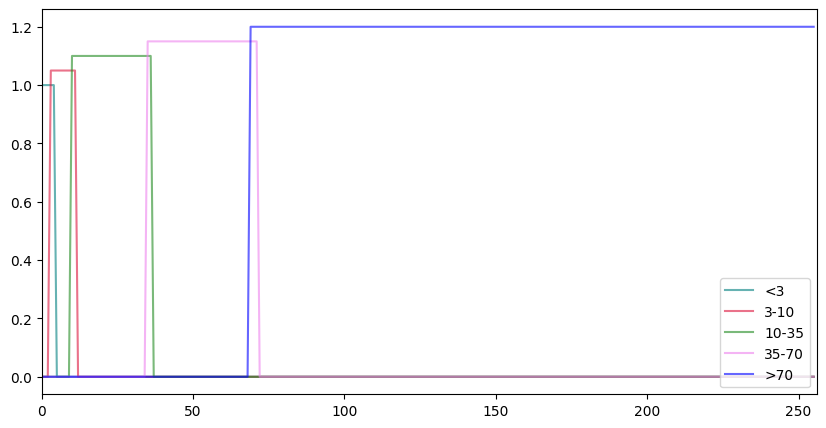

[[(0, 6), (6, 10)], [(0, 3), (3, 13), (13, 17)], [(6, 10), (10, 38), (38, 42)], [(31, 35), (35, 73), (73, 77)], [(65, 69), (69, 256)]]


In [17]:
supports = [filters.find_support(filt, EPSILON*1000, offset=i*0.05)[0] for i, filt in enumerate(windowed_sinc_filters)]
filters.plot_filters(names, supports, None, colours, plot_mask)

print([filters.find_support(filt, EPSILON*10, offset=i*0.05)[1] for i, filt in enumerate(windowed_sinc_filters)])

## Visibility histogram and close to ideal partitioning setup

create_named_configuration: MEERKAT
	(<Quantity 5109360.08350152 m>, <Quantity 2006852.56658911 m>, <Quantity -3238948.21751511 m>)
	GeodeticLocation(lon=<Longitude 21.44388889 deg>, lat=<Latitude -30.7110565 deg>, height=<Quantity 1086.6 m>)
create_configuration_from_file: 64 antennas/stations
create_visibility: created 80 times
create_visibility: 166400 rows, 0.009 GB


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


[10.325182825806106, 19.05542672393871, 39.9110093694777, 88.89737790899953, 242.64667322611257]


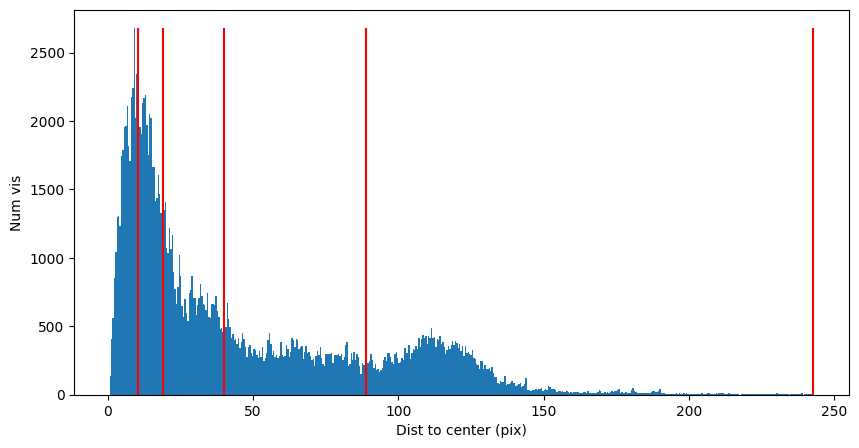

In [25]:
filters.generate_telescope_histogram(-35.0, "MEERKAT", 1e9, 500, 1, ha_interval = [-4, 4], \
                                     show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=0.00001849451,
                                     ignore_autocorrelation=True)